In [1]:
import sys
import json
import random
import warnings
from pathlib import Path
from datetime import datetime

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import timm

import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight


sys.path.append("../..")
from utils.seed import set_seed
from utils.config import save_run_manifest
from utils.dataset import get_dataloaders
from utils.engine import evaluate, run_phase
from utils.submission import (
    build_class_index_mapping,
    load_test_images,
    predict_competition_labels,
    print_label_distribution,
)

warnings.filterwarnings("ignore")

/Users/faqihfirmanpratama/miniforge3/envs/bdc/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# **EXPERIMENT CONFIG**

In [2]:
EXPERIMENT_CONFIG = {
    "seed": 42,
    "image_size": (224, 224),
    "batch_size": 32,
    "augmentation": {
        "rotation_range": 20,
        "shift_range": 0.2,
        "shear_range": 0.2,
        "zoom_range": 0.2,
        "brightness_range": [0.8, 1.2],
    },
    "model": {
        "backbone": "mobilenetv2_100",
        "fine_tune_at": 100,
    },
    "training": {
        "phase1_epochs": 10,
        "phase2_epochs": 10,
        "phase1_lr": 1e-3,
        "phase2_lr": 1e-5,
        "early_stop_patience_phase1": 2,
        "early_stop_patience_phase2": 5,
        "lr_reduce_factor": 0.5,
        "lr_reduce_patience": 3,
        "min_lr": 1e-7,
    },
}

In [3]:
RANDOM_SEED = EXPERIMENT_CONFIG["seed"]
set_seed(RANDOM_SEED)

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"PyTorch version : {torch.__version__}")
print(f"Device          : {device}")

PyTorch version : 2.12.1
Device          : mps


# **DATA LOADER**

In [4]:
TEST_DATA_DIR = Path("../../data/test")

RAW_FOLDER_TO_CLASS_NAME = {
    "0_Recyclable": "Recyclable",
    "1_Electronic": "Electronic",
    "2_Organic": "Organic",
}

CLASS_NAMES = sorted(RAW_FOLDER_TO_CLASS_NAME.values())
NUM_CLASSES = len(CLASS_NAMES)

test_image_count = len(list(TEST_DATA_DIR.glob("*.jpg")))
print(f"Kelas ({NUM_CLASSES}): {CLASS_NAMES}")
print(f"Total test gambar: {test_image_count}")

Kelas (3): ['Electronic', 'Organic', 'Recyclable']
Total test gambar: 1458


# **TRAIN-VAL SPLIT**

In [5]:
PROCESSED_DATA_DIR = Path("../../data/processed")
IMAGE_SIZE = EXPERIMENT_CONFIG["image_size"]
TRAIN_RATIO = 0.85
VAL_RATIO = 0.15

if not PROCESSED_DATA_DIR.exists():
    raise RuntimeError(
        f"'{PROCESSED_DATA_DIR}' belum ada. Jalankan notebook 00_data_split.ipynb dulu "
        "supaya folder train/val processed tersedia."
    )

TRAIN_DIR = PROCESSED_DATA_DIR / "train"
VAL_DIR = PROCESSED_DATA_DIR / "val"

print(f"Kelas ({NUM_CLASSES}): {CLASS_NAMES}")
for split_name, split_dir in [("train", TRAIN_DIR), ("val", VAL_DIR)]:
    total = sum(len(list((split_dir / cls).glob("*"))) for cls in CLASS_NAMES)
    print(f"Total {split_name:5}: {total} gambar")

Kelas (3): ['Electronic', 'Organic', 'Recyclable']
Total train: 22546 gambar
Total val  : 3981 gambar


# **PREPROCESSING & AUGMENTATION**

In [6]:
AUGMENTATION_CFG = EXPERIMENT_CONFIG["augmentation"]
BATCH_SIZE = EXPERIMENT_CONFIG["batch_size"]

NORMALIZE_MEAN = [0.5, 0.5, 0.5]
NORMALIZE_STD = [0.5, 0.5, 0.5]

train_transform = A.Compose(
    [
        A.Resize(*IMAGE_SIZE),
        A.HorizontalFlip(p=0.5),
        A.Affine(
            translate_percent={
                "x": (
                    -AUGMENTATION_CFG["shift_range"],
                    AUGMENTATION_CFG["shift_range"],
                ),
                "y": (
                    -AUGMENTATION_CFG["shift_range"],
                    AUGMENTATION_CFG["shift_range"],
                ),
            },
            shear=(
                -AUGMENTATION_CFG["shear_range"] * 90,
                AUGMENTATION_CFG["shear_range"] * 90,
            ),
            scale=(
                1 - AUGMENTATION_CFG["zoom_range"],
                1 + AUGMENTATION_CFG["zoom_range"],
            ),
            rotate=(
                -AUGMENTATION_CFG["rotation_range"],
                AUGMENTATION_CFG["rotation_range"],
            ),
            mode=cv2.BORDER_REPLICATE,
            p=1.0,
        ),
        A.RandomBrightnessContrast(
            brightness_limit=AUGMENTATION_CFG["brightness_range"][1] - 1.0,
            contrast_limit=0.0,
            p=1.0,
        ),
        A.Normalize(mean=NORMALIZE_MEAN, std=NORMALIZE_STD),
        ToTensorV2(),
    ]
)

eval_transform = A.Compose(
    [
        A.Resize(*IMAGE_SIZE),
        A.Normalize(mean=NORMALIZE_MEAN, std=NORMALIZE_STD),
        ToTensorV2(),
    ]
)

In [7]:
train_loader, val_loader, class_indices = get_dataloaders(
    TRAIN_DIR,
    VAL_DIR,
    CLASS_NAMES,
    train_transform,
    eval_transform,
    BATCH_SIZE,
)
idx_to_class = {v: k for k, v in class_indices.items()}
print(f"Class indices: {class_indices}")

Class indices: {'Electronic': 0, 'Organic': 1, 'Recyclable': 2}


In [8]:
train_labels = np.array([label for _, label in train_loader.dataset.samples])
unique_classes = np.unique(train_labels)

weights = compute_class_weight(
    class_weight="balanced", classes=unique_classes, y=train_labels
)
CLASS_WEIGHTS = dict(zip(unique_classes.tolist(), weights.tolist()))

class_weights_tensor = torch.tensor(
    [CLASS_WEIGHTS[i] for i in range(NUM_CLASSES)],
    dtype=torch.float32,
).to(device)

print("Class weights (untuk handle imbalance):")
for idx, w in CLASS_WEIGHTS.items():
    print(f"  {idx_to_class[idx]:12} (idx={idx}): weight={w:.4f}")

Class weights (untuk handle imbalance):
  Electronic   (idx=0): weight=2.2327
  Organic      (idx=1): weight=0.7036
  Recyclable   (idx=2): weight=0.8843


# **BUILD MODEL**

In [9]:
class MobileNetV2WasteClassifier(nn.Module):
    def __init__(self, num_classes: int, pretrained: bool = True) -> None:
        super().__init__()
        self.backbone = timm.create_model(
            EXPERIMENT_CONFIG["model"]["backbone"],
            pretrained=pretrained,
            num_classes=0,
            global_pool="",
        )
        feat_channels = self.backbone.num_features

        self.custom_conv2d = nn.Conv2d(feat_channels, 256, kernel_size=3, padding=1)
        self.relu = nn.ReLU(inplace=False)
        self.custom_maxpool = nn.MaxPool2d(kernel_size=2)
        self.global_pool = nn.AdaptiveAvgPool2d(1)

        self.classifier = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(inplace=False),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(inplace=False),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes),
        )

        self._init_head_weights()

    def _init_head_weights(self) -> None:
        # Only the custom head needs explicit init (the timm backbone already)
        # ships with its own pretrained/init weights, re-initializing it would
        # throw away the ImageNet features.
        for module in [self.custom_conv2d, self.classifier]:
            for m in module.modules():
                if isinstance(m, nn.Conv2d):
                    nn.init.kaiming_normal_(
                        m.weight, mode="fan_out", nonlinearity="relu"
                    )
                    if m.bias is not None:
                        nn.init.zeros_(m.bias)
                elif isinstance(m, nn.Linear):
                    nn.init.kaiming_normal_(
                        m.weight, mode="fan_out", nonlinearity="relu"
                    )
                    nn.init.zeros_(m.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.backbone(x)
        x = self.relu(self.custom_conv2d(x))
        x = self.custom_maxpool(x)
        x = self.global_pool(x)
        x = torch.flatten(x, 1)
        return self.classifier(x)


model = MobileNetV2WasteClassifier(NUM_CLASSES).to(device)

for param in model.backbone.parameters():
    param.requires_grad = False

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"Trainable params : {trainable:,} / {total:,}")

Trainable params : 2,990,723 / 5,214,595


# **TRAINING LOOP**

In [10]:
MODEL_NAME = "01_mobilenetv2"
RUN_ID = datetime.now().strftime("%Y%m%d_%H%M")
RUN_NAME = f"01_mobilenetv2_{RUN_ID}"
RUN_DIR = Path("../../models") / MODEL_NAME
RUN_DIR.mkdir(parents=True, exist_ok=True)

CHECKPOINT_PATH = RUN_DIR / "model.pt"
HISTORY_PATH = RUN_DIR / "training_history.json"
CONFIG_PATH = RUN_DIR / "config.json"

print(f"RUN_ID  : {RUN_ID}")
print(f"RUN_DIR : {RUN_DIR}")

RUN_ID  : 20260704_2355
RUN_DIR : ../../models/01_mobilenetv2


In [11]:
TRAINING_CONFIG = EXPERIMENT_CONFIG["training"]

history_combined = {"accuracy": [], "val_accuracy": [], "loss": [], "val_loss": []}

print("=" * 50)
print("PHASE 1: Feature Extraction (backbone frozen)")
print("=" * 50)

optimizer_phase1 = torch.optim.Adam(
    [p for p in model.parameters() if p.requires_grad],
    lr=TRAINING_CONFIG["phase1_lr"],
)
best_val_acc_phase1 = run_phase(
    model,
    optimizer_phase1,
    TRAINING_CONFIG["phase1_epochs"],
    TRAINING_CONFIG["early_stop_patience_phase1"],
    history_combined,
    "Phase1",
    train_loader=train_loader,
    val_loader=val_loader,
    class_weights_tensor=class_weights_tensor,
    device=device,
    lr_reduce_factor=TRAINING_CONFIG["lr_reduce_factor"],
    lr_reduce_patience=TRAINING_CONFIG["lr_reduce_patience"],
    min_lr=TRAINING_CONFIG["min_lr"],
)
phase1_epoch_count = len(history_combined["accuracy"])

PHASE 1: Feature Extraction (backbone frozen)


[Phase1] epoch 1/10 loss=1.8233 acc=0.6746 val_loss=0.4490 val_acc=0.8325 lr=1.00e-03


[Phase1] epoch 2/10 loss=0.6549 acc=0.7525 val_loss=0.4838 val_acc=0.8151 lr=1.00e-03


[Phase1] epoch 3/10 loss=0.6026 acc=0.7710 val_loss=0.4023 val_acc=0.8485 lr=1.00e-03


[Phase1] epoch 4/10 loss=0.5379 acc=0.8089 val_loss=0.4376 val_acc=0.8360 lr=1.00e-03


[Phase1] epoch 5/10 loss=0.4635 acc=0.8355 val_loss=0.3657 val_acc=0.8747 lr=1.00e-03


[Phase1] epoch 6/10 loss=0.4295 acc=0.8478 val_loss=0.3146 val_acc=0.8920 lr=1.00e-03


[Phase1] epoch 7/10 loss=0.4174 acc=0.8534 val_loss=0.3252 val_acc=0.8907 lr=1.00e-03


[Phase1] epoch 8/10 loss=0.3751 acc=0.8610 val_loss=0.3059 val_acc=0.8895 lr=1.00e-03
Early stopping triggered at epoch 8 (patience=2).


In [12]:
print("\n" + "=" * 50)
print("PHASE 2: Fine-tuning (unfreeze top backbone layers)")
print("=" * 50)

fine_tune_at = EXPERIMENT_CONFIG["model"]["fine_tune_at"]

backbone_params = list(model.backbone.named_parameters())
for _, param in backbone_params:
    param.requires_grad = True
for name, param in backbone_params[:fine_tune_at]:
    param.requires_grad = False

trainable_in_backbone = sum(1 for _, p in backbone_params if p.requires_grad)
print(
    f"Trainable param tensors di backbone: {trainable_in_backbone} / {len(backbone_params)}"
)

optimizer_phase2 = torch.optim.Adam(
    [p for p in model.parameters() if p.requires_grad],
    lr=TRAINING_CONFIG["phase2_lr"],
)
best_val_acc_phase2 = run_phase(
    model,
    optimizer_phase2,
    TRAINING_CONFIG["phase2_epochs"],
    TRAINING_CONFIG["early_stop_patience_phase2"],
    history_combined,
    "Phase2",
    train_loader=train_loader,
    val_loader=val_loader,
    class_weights_tensor=class_weights_tensor,
    device=device,
    lr_reduce_factor=TRAINING_CONFIG["lr_reduce_factor"],
    lr_reduce_patience=TRAINING_CONFIG["lr_reduce_patience"],
    min_lr=TRAINING_CONFIG["min_lr"],
)

torch.save(model.state_dict(), CHECKPOINT_PATH)
print(f"Model saved to {CHECKPOINT_PATH}")

with open(HISTORY_PATH, "w") as f:
    json.dump(history_combined, f)
print(f"History saved to {HISTORY_PATH}")

num_epochs_trained = len(history_combined["accuracy"])
best_val_accuracy = max(history_combined["val_accuracy"])
print(f"\nTotal epoch dilatih : {num_epochs_trained}")
print(f"Best val_accuracy   : {best_val_accuracy:.4f}")


PHASE 2: Fine-tuning (unfreeze top backbone layers)
Trainable param tensors di backbone: 56 / 156


[Phase2] epoch 1/10 loss=0.3878 acc=0.8600 val_loss=0.3116 val_acc=0.8958 lr=1.00e-05


[Phase2] epoch 2/10 loss=0.3603 acc=0.8704 val_loss=0.3078 val_acc=0.8905 lr=1.00e-05


[Phase2] epoch 3/10 loss=0.3324 acc=0.8776 val_loss=0.2915 val_acc=0.8988 lr=1.00e-05


[Phase2] epoch 4/10 loss=0.3299 acc=0.8816 val_loss=0.2836 val_acc=0.8980 lr=1.00e-05


...

[Phase2] epoch 6/10 loss=0.3026 acc=0.8884 val_loss=0.2759 val_acc=0.9061 lr=1.00e-05


[Phase2] epoch 7/10 loss=0.3058 acc=0.8895 val_loss=0.2612 val_acc=0.9108 lr=1.00e-05


[Phase2] epoch 8/10 loss=0.2822 acc=0.8950 val_loss=0.2587 val_acc=0.9091 lr=1.00e-05


[Phase2] epoch 9/10 loss=0.2843 acc=0.8948 val_loss=0.2463 val_acc=0.9171 lr=1.00e-05


[Phase2] epoch 10/10 loss=0.2779 acc=0.8988 val_loss=0.2414 val_acc=0.9194 lr=1.00e-05
Model saved to ../../models/01_mobilenetv2/model.pt
History saved to ../../models/01_mobilenetv2/training_history.json

Total epoch dilatih : 18
Best val_accuracy   : 0.9194


# **EVALUATION**

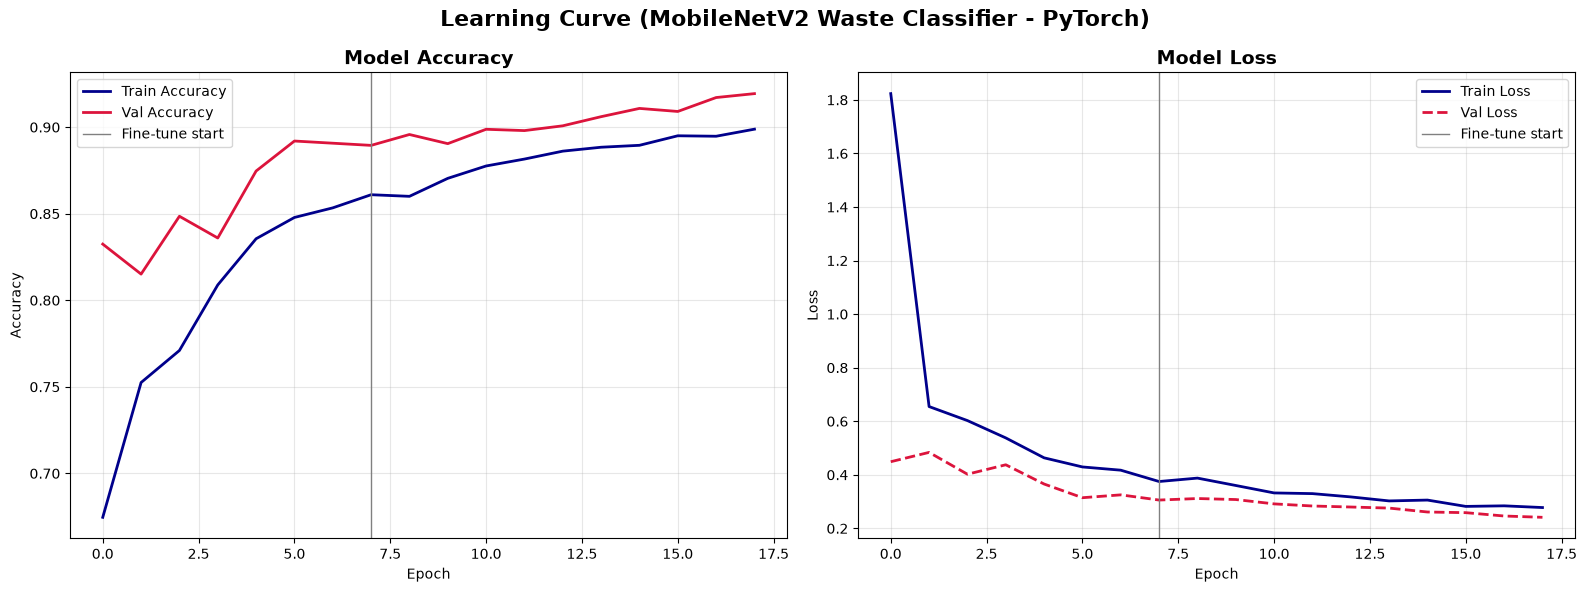

In [13]:
train_acc_hist = history_combined["accuracy"]
val_acc_hist = history_combined["val_accuracy"]
train_loss_hist = history_combined["loss"]
val_loss_hist = history_combined["val_loss"]

fig, (ax_acc, ax_loss) = plt.subplots(1, 2, figsize=(16, 6))

ax_acc.plot(train_acc_hist, label="Train Accuracy", color="darkblue", linewidth=2)
ax_acc.plot(val_acc_hist, label="Val Accuracy", color="crimson", linewidth=2)
ax_acc.axvline(
    x=phase1_epoch_count - 1,
    color="gray",
    linestyle="-",
    linewidth=1,
    label="Fine-tune start",
)
ax_acc.set_title("Model Accuracy", fontsize=14, fontweight="bold")
ax_acc.set_xlabel("Epoch")
ax_acc.set_ylabel("Accuracy")
ax_acc.legend()
ax_acc.grid(True, alpha=0.3)

ax_loss.plot(train_loss_hist, label="Train Loss", color="darkblue", linewidth=2)
ax_loss.plot(
    val_loss_hist, label="Val Loss", color="crimson", linewidth=2, linestyle="--"
)
ax_loss.axvline(
    x=phase1_epoch_count - 1,
    color="gray",
    linestyle="-",
    linewidth=1,
    label="Fine-tune start",
)
ax_loss.set_title("Model Loss", fontsize=14, fontweight="bold")
ax_loss.set_xlabel("Epoch")
ax_loss.set_ylabel("Loss")
ax_loss.legend()
ax_loss.grid(True, alpha=0.3)

plt.suptitle(
    "Learning Curve (MobileNetV2 Waste Classifier - PyTorch)",
    fontsize=16,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

In [14]:
final_criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
train_loss, train_accuracy = evaluate(model, train_loader, final_criterion, device)
val_loss, val_accuracy = evaluate(model, val_loader, final_criterion, device)

print("=" * 50)
print("EVALUASI FINAL")
print("=" * 50)
print(f"Train Accuracy : {train_accuracy * 100:.2f}%")
print(f"Val   Accuracy : {val_accuracy   * 100:.2f}%")
print(f"Train Loss     : {train_loss:.4f}")
print(f"Val   Loss     : {val_loss:.4f}")

EVALUASI FINAL
Train Accuracy : 92.87%
Val   Accuracy : 91.94%
Train Loss     : 0.1927
Val   Loss     : 0.2414


In [15]:
@torch.no_grad()
def predict_all(model, dataloader, device):
    model.eval()
    all_preds, all_labels = [], []
    for images, labels in dataloader:
        images = images.to(device)
        outputs = model(images)
        all_preds.append(outputs.argmax(1).cpu().numpy())
        all_labels.append(labels.numpy())
    return np.concatenate(all_preds), np.concatenate(all_labels)


pred_labels, true_labels = predict_all(model, val_loader, device)

print("\nClassification Report (Val Set):")
print(classification_report(true_labels, pred_labels, target_names=CLASS_NAMES))


Classification Report (Val Set):
              precision    recall  f1-score   support

  Electronic       0.88      0.95      0.91       595
     Organic       0.95      0.92      0.94      1886
  Recyclable       0.90      0.90      0.90      1500

    accuracy                           0.92      3981
   macro avg       0.91      0.93      0.92      3981
weighted avg       0.92      0.92      0.92      3981



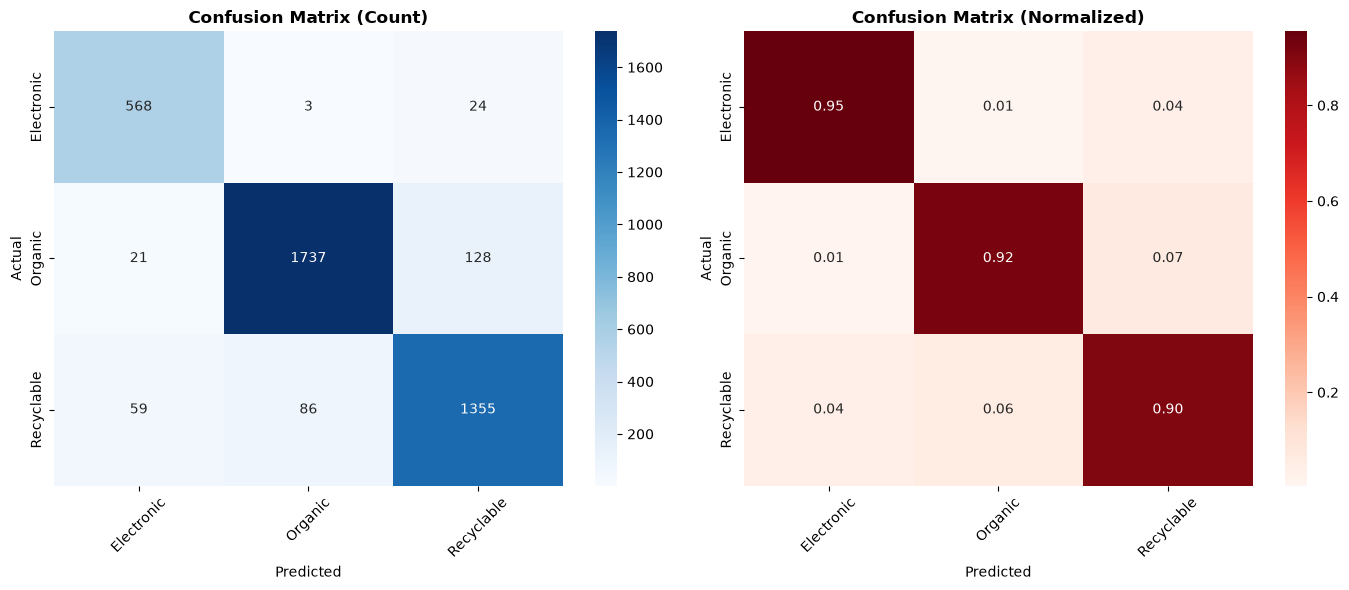

In [16]:
conf_matrix = confusion_matrix(true_labels, pred_labels)
conf_matrix_normalized = (
    conf_matrix.astype("float") / conf_matrix.sum(axis=1)[:, np.newaxis]
)

fig, (ax_count, ax_norm) = plt.subplots(1, 2, figsize=(14, 6))

sns.heatmap(
    conf_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    ax=ax_count,
)
ax_count.set_title("Confusion Matrix (Count)", fontweight="bold")
ax_count.set_xlabel("Predicted")
ax_count.set_ylabel("Actual")
ax_count.tick_params(axis="x", rotation=45)

sns.heatmap(
    conf_matrix_normalized,
    annot=True,
    fmt=".2f",
    cmap="Reds",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    ax=ax_norm,
)
ax_norm.set_title("Confusion Matrix (Normalized)", fontweight="bold")
ax_norm.set_xlabel("Predicted")
ax_norm.set_ylabel("Actual")
ax_norm.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

# **INFERENCE**

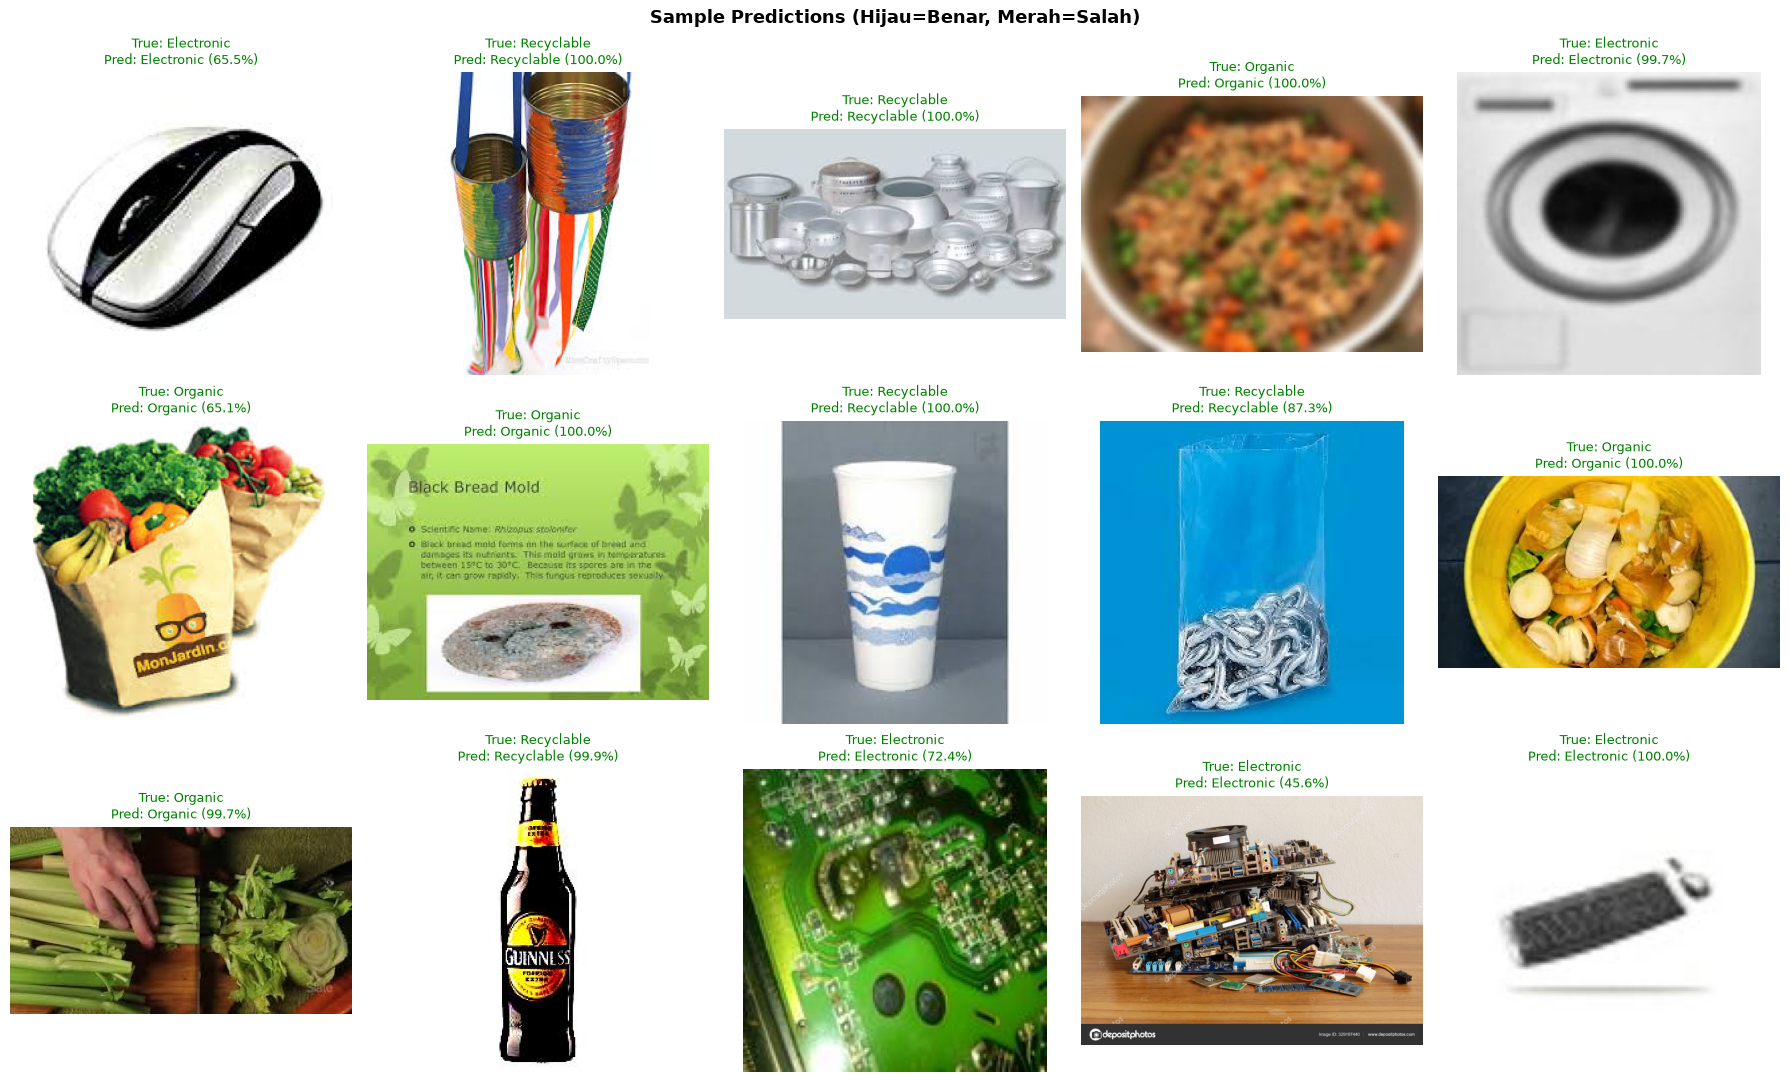

In [17]:
SAMPLES_PER_CLASS = 5  # 3 kelas x 5 = 15 total sample yang divisualisasi

val_samples = []
for cls_name in CLASS_NAMES:
    cls_dir = VAL_DIR / cls_name
    all_imgs = (
        list(cls_dir.glob("*.jpg"))
        + list(cls_dir.glob("*.jpeg"))
        + list(cls_dir.glob("*.png"))
    )
    chosen = random.sample(all_imgs, min(SAMPLES_PER_CLASS, len(all_imgs)))
    for img_path in chosen:
        val_samples.append((img_path, cls_name))

random.shuffle(val_samples)

model.eval()
sample_batch = torch.stack(
    [
        eval_transform(image=np.array(Image.open(p).convert("RGB")))["image"]
        for p, _ in val_samples
    ]
).to(device)

with torch.no_grad():
    sample_logits = model(sample_batch)
    sample_probs = torch.softmax(sample_logits, dim=1).cpu().numpy()

fig, axes = plt.subplots(3, 5, figsize=(18, 11))
axes = axes.flatten()

for i, (img_path, true_label) in enumerate(val_samples):
    pred_label = CLASS_NAMES[np.argmax(sample_probs[i])]
    confidence = np.max(sample_probs[i]) * 100
    is_correct = true_label == pred_label

    axes[i].imshow(Image.open(img_path).convert("RGB"))
    axes[i].set_title(
        f"True: {true_label}\nPred: {pred_label} ({confidence:.1f}%)",
        color="green" if is_correct else "red",
        fontsize=9,
    )
    axes[i].axis("off")

plt.suptitle(
    "Sample Predictions (Hijau=Benar, Merah=Salah)", fontsize=13, fontweight="bold"
)
plt.tight_layout()
plt.show()

# **SAVE CONFIG**

In [18]:
EXPERIMENT_CONFIG["run_id"] = RUN_ID
EXPERIMENT_CONFIG["run_name"] = RUN_NAME
EXPERIMENT_CONFIG["model_name"] = "mobilenetv2_waste_classifier_pytorch"
EXPERIMENT_CONFIG["base_architecture"] = (
    "timm mobilenetv2_100 (imagenet pretrained, num_classes=0 feature extractor)"
)
EXPERIMENT_CONFIG["input_shape"] = [3, IMAGE_SIZE[0], IMAGE_SIZE[1]]
EXPERIMENT_CONFIG["num_classes"] = NUM_CLASSES
EXPERIMENT_CONFIG["class_names"] = CLASS_NAMES
EXPERIMENT_CONFIG["class_indices"] = class_indices
EXPERIMENT_CONFIG["class_weights"] = {
    idx_to_class[int(k)]: v for k, v in CLASS_WEIGHTS.items()
}
EXPERIMENT_CONFIG["pytorch_version"] = torch.__version__
EXPERIMENT_CONFIG["device"] = str(device)
EXPERIMENT_CONFIG["dataset"] = {
    "train_dir": str(TRAIN_DIR),
    "val_dir": str(VAL_DIR),
    "train_ratio": TRAIN_RATIO,
    "val_ratio": VAL_RATIO,
    "train_samples": len(train_loader.dataset),
    "val_samples": len(val_loader.dataset),
}
EXPERIMENT_CONFIG["training"]["epochs_trained_total"] = num_epochs_trained
EXPERIMENT_CONFIG["callbacks"] = {
    "early_stopping": {
        "monitor": "val_accuracy",
        "patience_phase1": TRAINING_CONFIG["early_stop_patience_phase1"],
        "patience_phase2": TRAINING_CONFIG["early_stop_patience_phase2"],
        "restore_best_weights": True,
    },
    "reduce_lr_on_plateau": {
        "monitor": "val_loss",
        "factor": TRAINING_CONFIG["lr_reduce_factor"],
        "patience": TRAINING_CONFIG["lr_reduce_patience"],
        "min_lr": TRAINING_CONFIG["min_lr"],
    },
    "model_checkpoint": {
        "monitor": "val_accuracy",
        "save_best_only": True,
    },
}

results = {
    "best_val_accuracy": best_val_accuracy,
    "final_train_accuracy": train_accuracy,
    "final_val_accuracy": val_accuracy,
    "final_train_loss": train_loss,
    "final_val_loss": val_loss,
}

artifacts = {
    "model_path": str(CHECKPOINT_PATH),
    "training_history_path": str(HISTORY_PATH),
}

manifest = save_run_manifest(EXPERIMENT_CONFIG, results, artifacts, CONFIG_PATH)
print(f"Config saved to: {CONFIG_PATH}")
print(json.dumps(manifest, indent=2))

Config saved to: ../../models/01_mobilenetv2/config.json
{
  "run_id": "20260704_2355",
  "run_name": "01_mobilenetv2_20260704_2355",
  "timestamp": "2026-07-05T00:17:34.917872",
  "seed": 42,
  "image_size": [
    224,
    224
  ],
  "batch_size": 32,
  "augmentation": {
    "rotation_range": 20,
    "shift_range": 0.2,
    "shear_range": 0.2,
    "zoom_range": 0.2,
    "brightness_range": [
      0.8,
      1.2
    ]
  },
  "model": {
    "backbone": "mobilenetv2_100",
    "fine_tune_at": 100
  },
  "training": {
    "phase1_epochs": 10,
    "phase2_epochs": 10,
    "phase1_lr": 0.001,
    "phase2_lr": 1e-05,
    "early_stop_patience_phase1": 2,
    "early_stop_patience_phase2": 5,
    "lr_reduce_factor": 0.5,
    "lr_reduce_patience": 3,
    "min_lr": 1e-07,
    "epochs_trained_total": 18
  },
  "model_name": "mobilenetv2_waste_classifier_pytorch",
  "base_architecture": "timm mobilenetv2_100 (imagenet pretrained, num_classes=0 feature extractor)",
  "input_shape": [
    3,
    224,

# **SUBMISSION**

In [19]:
ENGLISH_TO_COMPETITION_LABEL = {
    class_name: int(raw_folder.split("_")[0])
    for raw_folder, class_name in RAW_FOLDER_TO_CLASS_NAME.items()
}
COMPETITION_LABEL_TO_NAME = {
    label: name for name, label in ENGLISH_TO_COMPETITION_LABEL.items()
}

CLASS_INDEX_TO_COMPETITION_LABEL = build_class_index_mapping(
    class_indices,
    ENGLISH_TO_COMPETITION_LABEL,
)

print("Mapping model index -> competition label:")
for model_idx, comp_label in sorted(CLASS_INDEX_TO_COMPETITION_LABEL.items()):
    print(
        f"  model idx {model_idx} ({idx_to_class[model_idx]:12}) -> competition label {comp_label} ({COMPETITION_LABEL_TO_NAME[comp_label]})"
    )

Mapping model index -> competition label:
  model idx 0 (Electronic  ) -> competition label 1 (Electronic)
  model idx 1 (Organic     ) -> competition label 2 (Organic)
  model idx 2 (Recyclable  ) -> competition label 0 (Recyclable)


In [20]:
submission_template = pd.read_csv("../../submission/template_submission.csv")
test_ids = submission_template["id"].tolist()
print(f"Total test IDs: {len(test_ids)}")
print(f"Contoh IDs: {test_ids[:5]} ... {test_ids[-5:]}")


def eval_preprocess(image: np.ndarray) -> np.ndarray:
    return eval_transform(image=image)["image"].numpy()


test_array, valid_ids = load_test_images(
    TEST_DATA_DIR,
    test_ids,
    eval_preprocess,
    IMAGE_SIZE,
)
print(f"Test array shape: {test_array.shape}")

competition_preds = predict_competition_labels(
    model,
    test_array,
    CLASS_INDEX_TO_COMPETITION_LABEL,
    batch_size=BATCH_SIZE,
)
competition_pred_names = [COMPETITION_LABEL_TO_NAME[p] for p in competition_preds]
print_label_distribution(
    competition_pred_names, list(COMPETITION_LABEL_TO_NAME.values())
)

Total test IDs: 1458
Contoh IDs: [1, 2, 3, 4, 5] ... [1454, 1455, 1456, 1457, 1458]
Test array shape: (1458, 3, 224, 224)
Label distribution (1458 predictions):
  Recyclable: 438 (30.0%)
  Electronic: 267 (18.3%)
  Organic: 753 (51.6%)


### save submission

In [21]:
submission_df = pd.DataFrame(
    {
        "id": valid_ids,
        "predicted": competition_preds,
    }
)

submission_path = f"../../submission/submission_{MODEL_NAME}_{RUN_ID}.csv"
submission_df.to_csv(submission_path, index=False)

print(f"Submission saved to: {submission_path}")
print(f"Total rows: {len(submission_df)}")
print("\nSample submission:")
print(submission_df.head(10).to_string(index=False))

Submission saved to: ../../submission/submission_01_mobilenetv2_20260704_2355.csv
Total rows: 1458

Sample submission:
 id  predicted
  1          2
  2          2
  3          2
  4          1
  5          0
  6          0
  7          2
  8          0
  9          1
 10          2


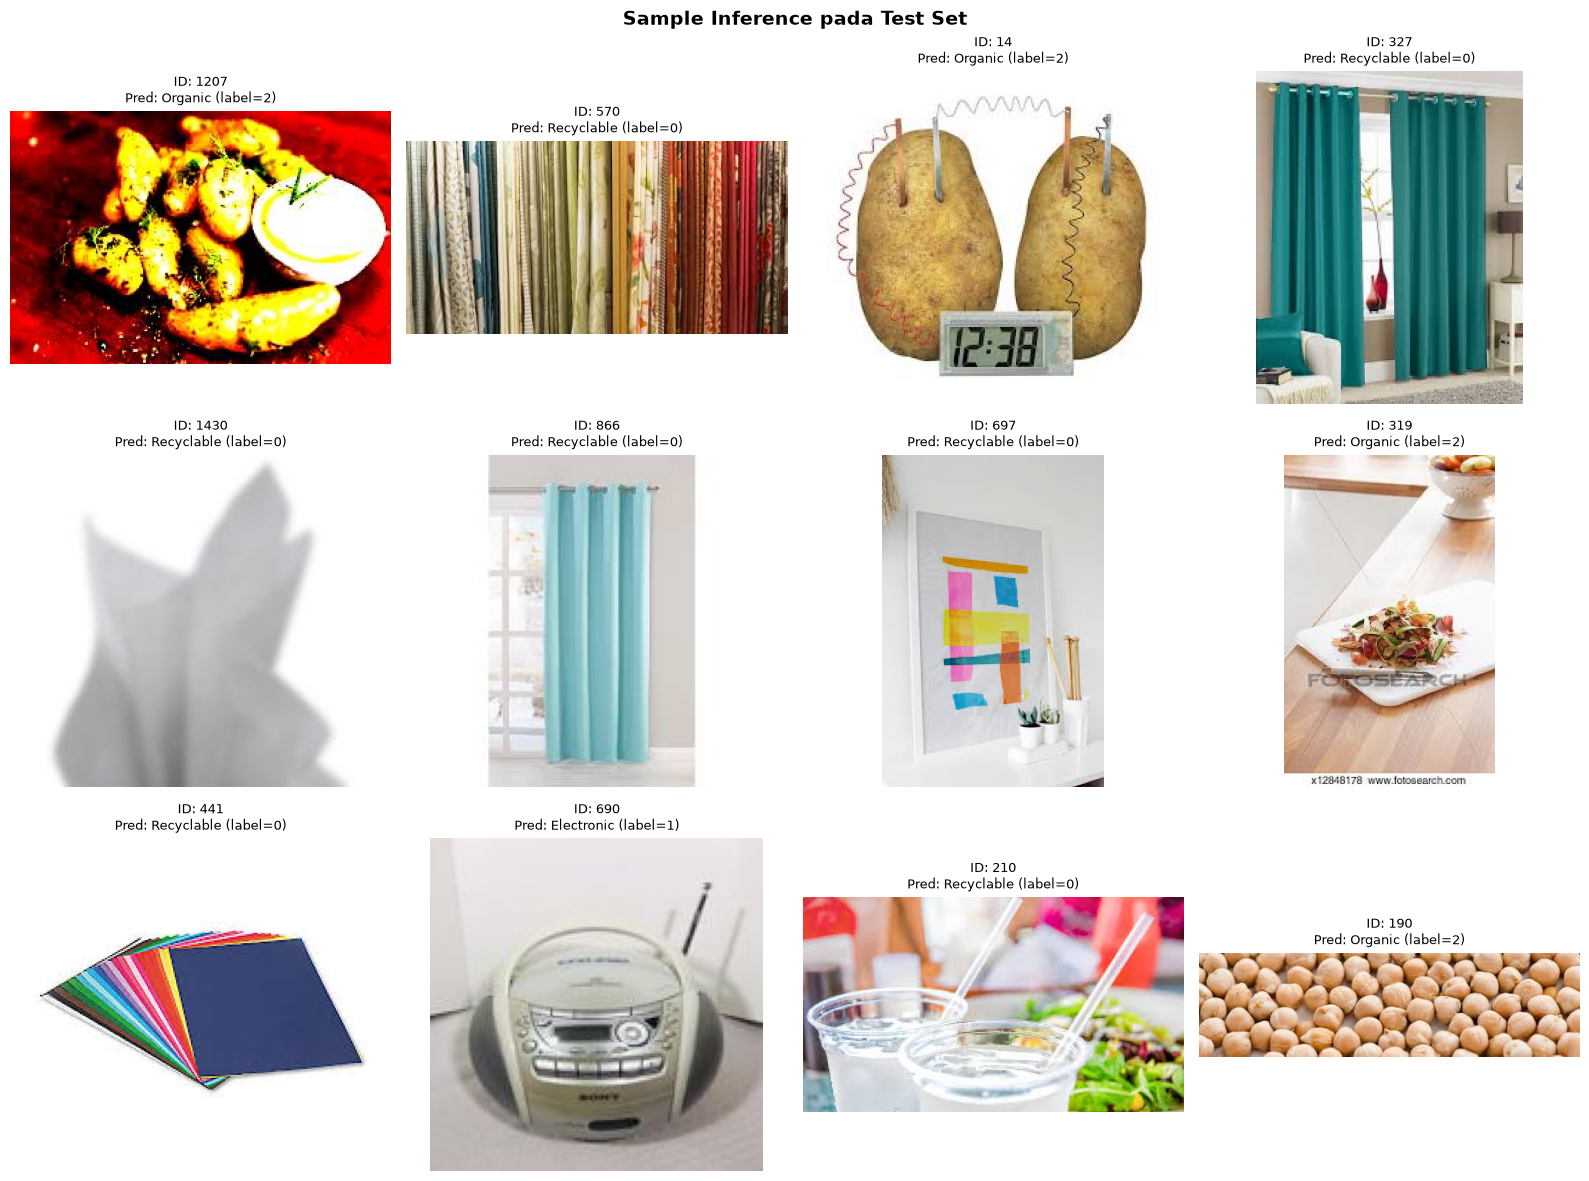

In [22]:
NUM_VIZ = 12
sample_indices = random.sample(range(len(valid_ids)), NUM_VIZ)

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

for plot_idx, sample_idx in enumerate(sample_indices):
    img_id = valid_ids[sample_idx]
    img_path = TEST_DATA_DIR / f"{img_id}.jpg"
    img_raw = Image.open(img_path).convert("RGB")

    pred_comp = competition_preds[sample_idx]
    pred_name = COMPETITION_LABEL_TO_NAME[pred_comp]

    axes[plot_idx].imshow(img_raw)
    axes[plot_idx].set_title(
        f"ID: {img_id}\nPred: {pred_name} (label={pred_comp})",
        fontsize=9,
    )
    axes[plot_idx].axis("off")

plt.suptitle("Sample Inference pada Test Set", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()